# *Budget Estimation*

## *Data Attribution*


This dataset was constructed from 145 Israeli Ministry of Education research grant records. Each row represents one funded research proposal, extracted from a "golden triangle" of three source documents per proposal:

1. **Call for proposals** (קול קורא) — the funding call under which the proposal was submitted
2. **Research proposal** (הצעת מחקר) — the PI's submitted research design
3. **Budget breakdown** (פילוח תקציבי) — the itemized budget allocation for the proposal

Structured fields (25 attributes per record, including study design parameters, methodology flags, and budgeted person-work) were extracted from each triangle using Google NotebookLM, then consolidated, validated, and merged into a single structured table through manual QA.


## *Data Dictionary*



Field definitions as specified in the extraction prompt given to NotebookLM.

| Column | Type | Description |
|---|---|---|
| `call_title` | string | Title of the call for proposals (קול קורא) |
| `pi_name` | string | Name of the principal investigator(s) |
| `proposal_title` | string | Title of the submitted research proposal |
| `duration_months` | int | Research duration in months (`-1` = unknown) |
| `site_count` | int | Number of research sites / participating schools (`-1` = unknown) |
| `subject_count` | int | Number of research subjects / participants (`-1` = unknown) |
| `target_populations_count` | int | Number of distinct target populations (`-1` = unknown) |
| `data_waves_count` | int | Number of data collection waves (`-1` = unknown) |
| `has_surveys` | binary | Uses questionnaires/surveys (1 = yes, 0 = no, -1 = unknown) |
| `has_interviews` | binary | Uses interviews (1/0/-1) |
| `has_focus_groups` | binary | Uses focus groups (1/0/-1) |
| `has_observations` | binary | Uses observations (1/0/-1) |
| `has_tests` | binary | Uses tests/assessments (1/0/-1) |
| `collection_mode` | categorical | Primary data collection mode: `Online`, `Field`, `SurveyInstitute`, `Mixed`, `Unknown` |
| `tool_development_type` | categorical | Level of instrument development: `Existing`, `Adaptation`, `New`, `Validation`, `Unknown` |
| `languages_count` | int | Number of languages used (`-1` = unknown) |
| `requires_translation` | binary | Requires translation / cultural adaptation (1/0/-1) |
| `uses_admin_data` | binary | Uses administrative / research-room data (1/0/-1) |
| `requires_data_linking` | binary | Requires linking/merging of datasets (1/0/-1) |
| `is_complex_design` | binary | Complex design — control group / complex population (1/0/-1) |
| `budgeted_person_work` | int/float | Total budgeted amount for personnel work, in NIS (monetary value, not months; `-1` = unknown) |
| `has_external_services` | binary | Purchases external services (surveys, statistics, editing) (1/0/-1) |
| `deliverables_level` | categorical | Scope of deliverables: `Standard`, `Extended`, `Unknown` |
| `has_special_equipment` | binary | Includes dedicated equipment in budget (1/0/-1) |
| `is_multidisciplinary` | binary | Multidisciplinary research (1/0/-1) |

## *Setup*

### *Imports*

In [83]:
import pandas as pd
import numpy as np
import plotnine as pln
from scipy.stats import skew, kurtosis

### *Dataset Loading*

In [84]:
df = pd.read_csv(r"C:\Users\idowe\MyProjects\MOECSO\budget_estimation\research_table_with_budget_and_sources.csv", encoding="utf-8-sig")

In [85]:
df.head()

,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,...,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,אורטל_סלובדין_21.txt,קול קורא מס' 2021.11/27 למחקר בנושא החינוך בחב...,פרופ' אורטל סלובודין,"הארון הכפול: נוער להט""בי במערכת החינוך הערבית ...",18,80,80,-1,-1,0,...,-1,0,0,0,125280.0,1,Unknown,0,-1,300000
1,אורטל_סלובדין_24.txt,קול קורא מס' 15/5.2024 למחקר בנושא חינוך בצל מ...,"פרופ' אורטל סלובודין, פרופ' הללי פינסון",חסמים באיתור ובהשתתפות תלמידים/ות מהחברה הבדוא...,18,8,100,2,1,0,...,1,1,0,1,134676.0,1,Extended,0,1,200000
2,אורי_כהן_21.txt,קול קורא מס' 27/11.2021 למחקר בנושא החינוך בחב...,אורי כהן,יחסי גומלין בין מנהל החינוך ברשות המקומית לבתי...,18,25,65,3,-1,0,...,-1,0,0,0,248400.0,0,Unknown,0,-1,300000
3,אורית_חזן_24.txt,"קול קורא מס' 27/8.24 למחקר בנושא ""קבלת החלטות ...",אורית חזן,קבלת החלטות בית ספריות מבוססות נתונים בקרב מנה...,16,25,175,1,2,1,...,0,0,0,1,217500.0,1,Standard,0,0,250000
4,אורלי_ליפקה_24.txt,קול קורא מס 15/5.2024 למחקר בנושא חינוך בצל מש...,"אורלי ליפקה, תמר קציר",חוסן אישי ותחושת שלומות של מורים בחברה הערבית ...,18,-1,1255,2,2,1,...,1,0,0,1,135000.0,1,Extended,0,1,200000


## *EDA - Explorary Data Analysis*

### *Structural analysis*

In [86]:
df.shape

(140, 27)

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   source_file               140 non-null    str    
 1   call_title                140 non-null    str    
 2   pi_name                   140 non-null    str    
 3   proposal_title            140 non-null    str    
 4   duration_months           140 non-null    int64  
 5   site_count                140 non-null    int64  
 6   subject_count             140 non-null    int64  
 7   target_populations_count  140 non-null    int64  
 8   data_waves_count          140 non-null    int64  
 9   has_surveys               140 non-null    int64  
 10  has_interviews            140 non-null    int64  
 11  has_focus_groups          140 non-null    int64  
 12  has_observations          140 non-null    int64  
 13  has_tests                 140 non-null    int64  
 14  collection_mode      

### *Missing values*

#### *Missing values statistics*

As expeected there are no NaN values because in the prompt we defined unkhown as -1.

In [88]:
df.isnull() # check NaN in each parameter

,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,...,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
136,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
137,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
138,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



What the `-1` counts in each column actually mean (based on 140 records):

- **Text fields** (`source_file`, `call_title`, `pi_name`, `proposal_title`): 0% missing. These are just copied names/titles from the documents, so there's basically always something there.

- **`duration_months`** (0.7%, 1 missing): Almost every proposal says how long the study will take. Makes sense — it's a basic thing every proposal has to state.

- **`site_count`** (52.9%, 74 missing): This is the big one. More than half the proposals don't say how many schools/sites are involved. Probably because a lot of studies (online surveys, phone interviews, etc.) don't really work through a fixed number of "sites," or the researcher just didn't bother specifying it.

- **`subject_count`** (26.4%, 37 missing): About 1 in 4 proposals don't say how many people will take part. Could be because at the proposal stage the exact sample size wasn't decided yet.

- **`target_populations_count`** (24.3%, 34 missing): Similar story — a lot of proposals don't clearly say how many different population groups they're studying, especially when there's really just one group and it's obvious.

- **`data_waves_count`** (36.4%, 51 missing): Missing a lot too. Probably because many studies only collect data once (not in "waves"), so this question doesn't really apply, or it just wasn't stated.

- **`has_surveys`** (0.7%, 1 missing): Almost always known. Whether a study uses surveys or not is usually obvious from reading the proposal.

**Bottom line:** The missing values aren't random. They're mostly concentrated in the "give me an exact number" fields (site count, subject count, target populations, data waves) — because these require someone to have actually written a specific number down (mostly those are paramters that determined during the research). The yes/no methodology questions, on the other hand, are almost always answered.

In [89]:
counts = (df == -1).sum()
percent = (counts / len(df) * 100).round(1)

pd.DataFrame({
            "count": counts,
            "percent": percent
              })

,count,percent
source_file,0,0.0
call_title,0,0.0
pi_name,0,0.0
proposal_title,0,0.0
duration_months,1,0.7
site_count,74,52.9
subject_count,37,26.4
target_populations_count,34,24.3
data_waves_count,51,36.4
has_surveys,1,0.7


#### *Data cleaning*

converting (-1) to nan for applying statistics methods later

In [90]:
cols_with_unknown = df.select_dtypes(include=["number"]).columns.tolist() # collecting columns name's with uncertainty
df_clean = df.copy() # creating clean data frame
df_clean[cols_with_unknown] = df_clean[cols_with_unknown].replace(-1, np.nan)

In [91]:
df_clean.isnull()

,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,...,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,False,False,False,False,False,False,False,True,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,False,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
136,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
137,False,False,False,False,False,True,True,True,True,False,...,True,True,True,True,False,False,False,False,True,False
138,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### *Statistical summary*

In [92]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,139.0,25.366906,9.792147,16.0,18.00,18.0,36.00,60.0
site_count,66.0,51.590909,79.761370,1.0,8.25,25.0,60.00,500.0
subject_count,103.0,1156.184466,2170.224118,25.0,162.50,500.0,1130.00,14400.0
target_populations_count,106.0,2.367925,1.044947,1.0,2.00,2.0,3.00,7.0
data_waves_count,89.0,2.202247,0.894170,1.0,2.00,2.0,3.00,5.0
has_surveys,139.0,0.848921,0.359421,0.0,1.00,1.0,1.00,1.0
has_interviews,139.0,0.712230,0.454361,0.0,0.00,1.0,1.00,1.0
has_focus_groups,138.0,0.224638,0.418864,0.0,0.00,0.0,0.00,1.0
has_observations,138.0,0.239130,0.428106,0.0,0.00,0.0,0.00,1.0
has_tests,138.0,0.304348,0.461807,0.0,0.00,0.0,1.00,1.0


### *Correlation Analysis*

#### *Setup*

In [93]:
binary_cols = ["has_surveys", "has_interviews", "has_focus_groups", "has_observations",
               "has_tests", "requires_translation", "uses_admin_data",
               "requires_data_linking", "is_complex_design", "has_external_services",
               "has_special_equipment", "is_multidisciplinary"]

continuous_cols = ["duration_months", "site_count", "subject_count",
                    "target_populations_count", "data_waves_count",
                    "languages_count", "budgeted_person_work", "target_budget"]

numeric_cols = df_clean.select_dtypes(include = ["number"]).columns.tolist()

In [94]:
def corr_heatmap(matrix, title):
    long = matrix.reset_index().melt(id_vars="index")
    long.columns = ["feature_1", "feature_2", "correlation"]
    return (
        pln.ggplot(long, pln.aes("feature_1", "feature_2", fill="correlation"))
        + pln.geom_tile()
        + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
        + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 8))
        + pln.labs(title=title)
    )

#### *Numeric varaibles analsys*

##### *Pearson correlation analysis*

In [95]:
linear_corr_continuous = df_clean[continuous_cols].corr(method="pearson")
linear_corr_continuous

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,languages_count,budgeted_person_work,target_budget
duration_months,1.000000,-0.030149,0.240052,0.147206,0.566380,0.108666,0.609122,0.624639
site_count,-0.030149,1.000000,0.488942,0.010469,-0.101831,0.271170,0.136482,0.117471
subject_count,0.240052,0.488942,1.000000,0.318294,0.311530,0.216596,0.279989,0.294227
target_populations_count,0.147206,0.010469,0.318294,1.000000,0.284235,0.359843,0.228283,0.263483
data_waves_count,0.566380,-0.101831,0.311530,0.284235,1.000000,0.016672,0.373371,0.404000
languages_count,0.108666,0.271170,0.216596,0.359843,0.016672,1.000000,0.239531,0.254658
budgeted_person_work,0.609122,0.136482,0.279989,0.228283,0.373371,0.239531,1.000000,0.961213
target_budget,0.624639,0.117471,0.294227,0.263483,0.404000,0.254658,0.961213,1.000000


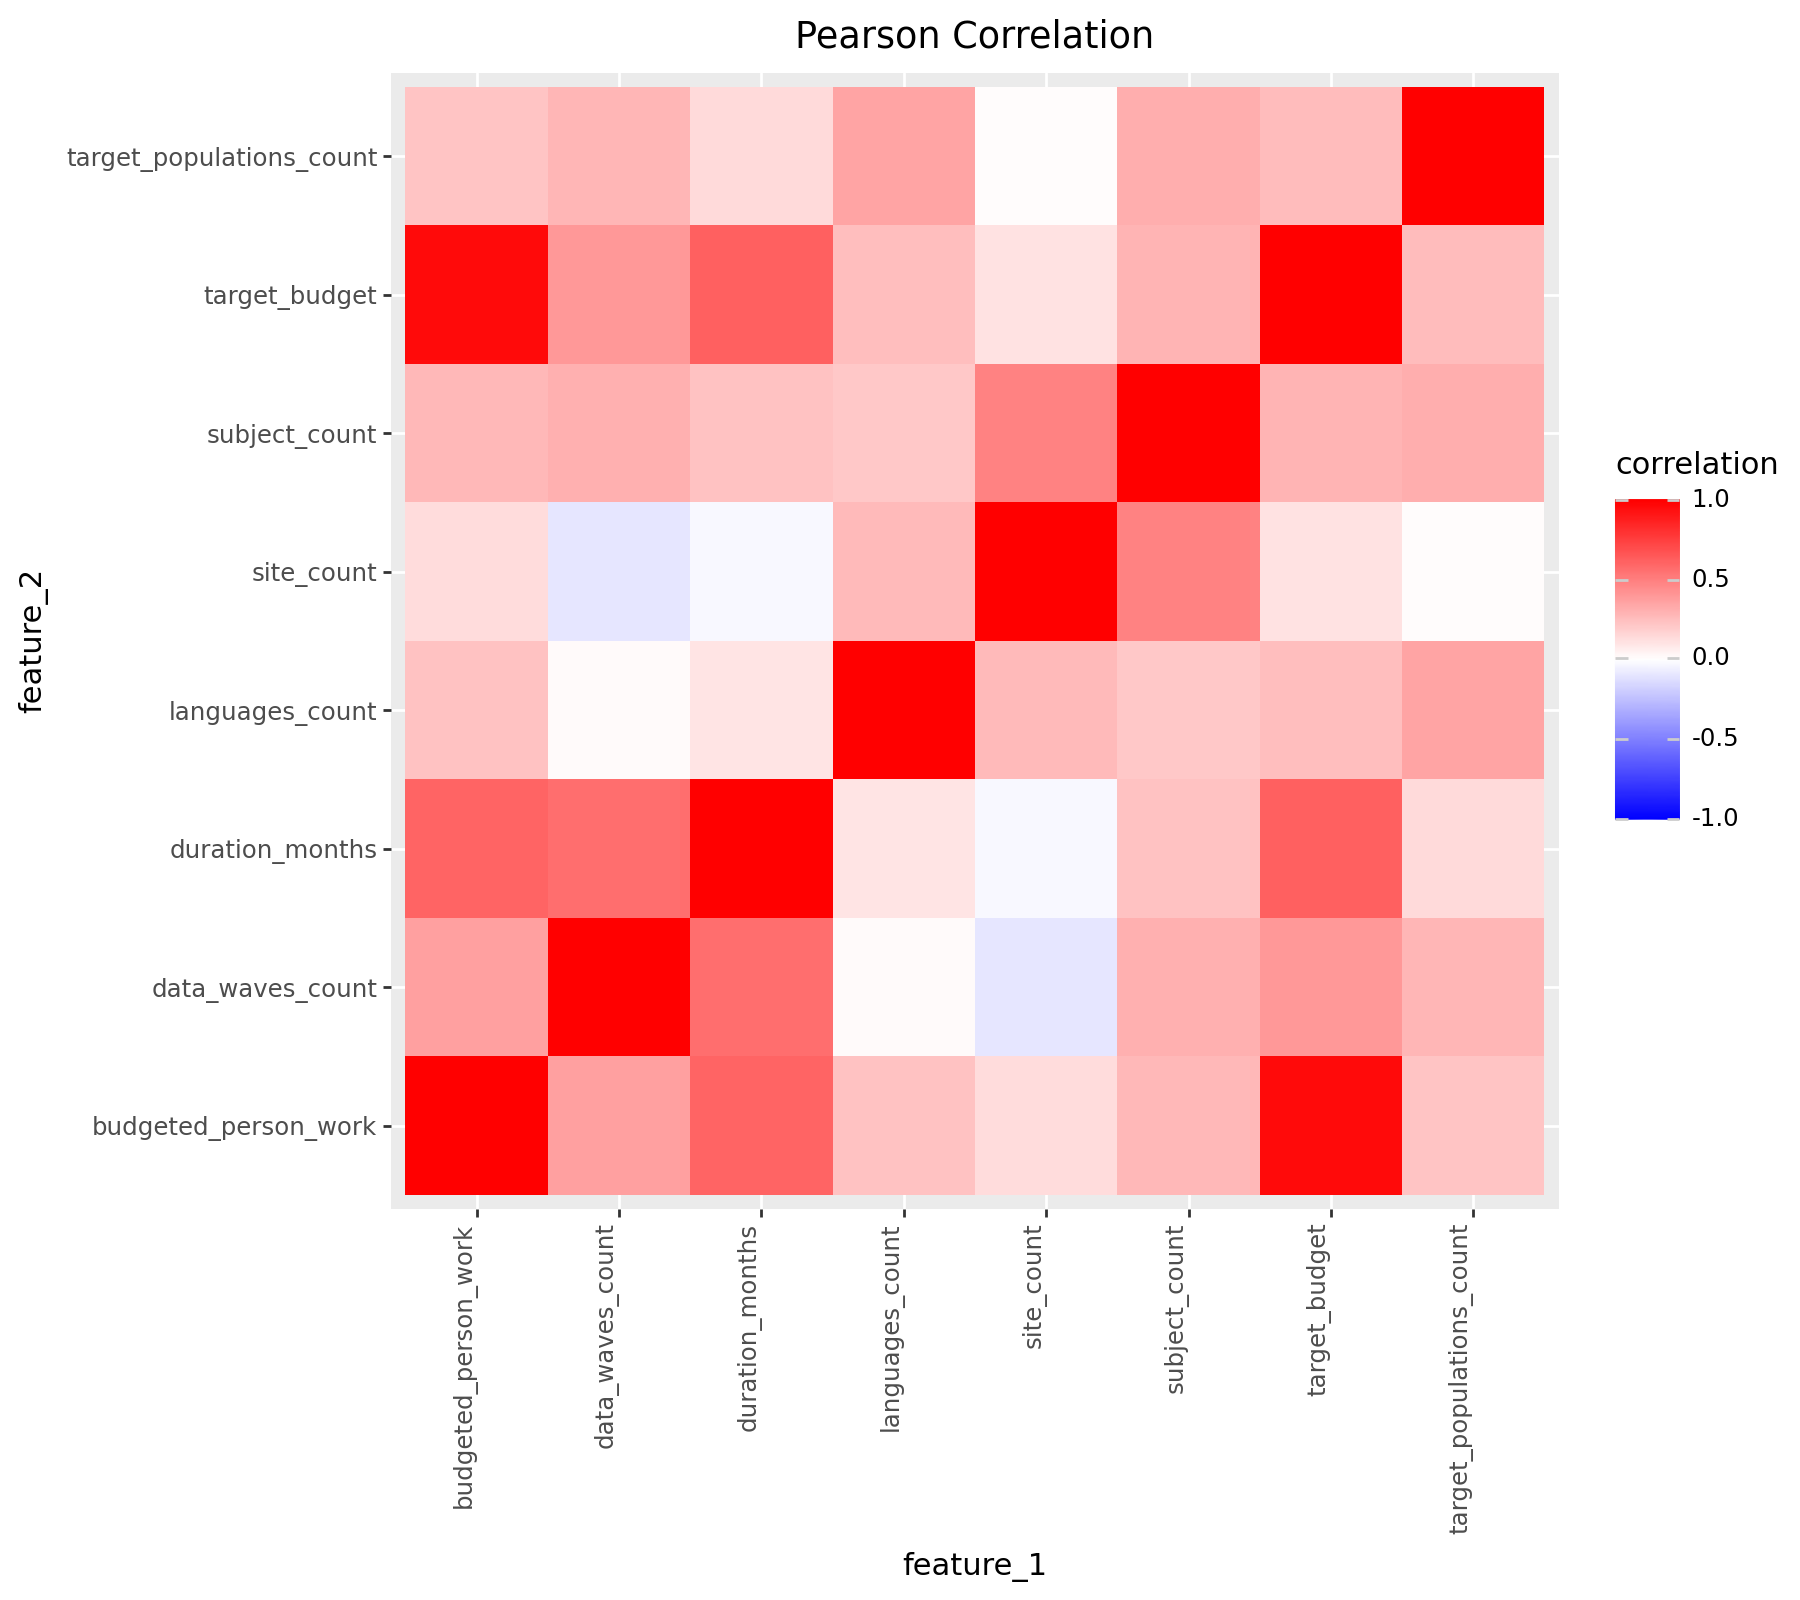

In [96]:
corr_heatmap(linear_corr_continuous, "Pearson Correlation")

In [97]:
linear_corr_binary = df_clean[binary_cols].corr(method="pearson")
linear_corr_binary

,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,has_external_services,has_special_equipment,is_multidisciplinary
has_surveys,1.000000,-0.135034,0.228037,-0.046268,0.061001,0.163912,0.027656,0.154939,0.295790,-0.040640,0.072267,0.237812
has_interviews,-0.135034,1.000000,0.114257,0.133497,-0.271657,0.062654,0.034482,-0.058656,0.012228,0.198841,-0.156497,-0.050382
has_focus_groups,0.228037,0.114257,1.000000,0.105304,0.059064,0.298732,-0.002765,0.109917,0.120873,0.072849,-0.090606,0.146374
has_observations,-0.046268,0.133497,0.105304,1.000000,0.219918,-0.003218,0.223978,0.042334,0.070159,-0.089175,0.005836,0.186232
has_tests,0.061001,-0.271657,0.059064,0.219918,1.000000,0.082920,0.215972,0.192342,0.332879,-0.302225,0.204034,0.397304
requires_translation,0.163912,0.062654,0.298732,-0.003218,0.082920,1.000000,0.232350,0.271288,0.120011,-0.085410,0.141946,0.323814
uses_admin_data,0.027656,0.034482,-0.002765,0.223978,0.215972,0.232350,1.000000,0.616417,0.163967,-0.104145,0.111009,0.196894
requires_data_linking,0.154939,-0.058656,0.109917,0.042334,0.192342,0.271288,0.616417,1.000000,0.182534,-0.055859,0.028569,0.173528
is_complex_design,0.295790,0.012228,0.120873,0.070159,0.332879,0.120011,0.163967,0.182534,1.000000,-0.201236,0.022727,0.526486
has_external_services,-0.040640,0.198841,0.072849,-0.089175,-0.302225,-0.085410,-0.104145,-0.055859,-0.201236,1.000000,0.025679,-0.206331


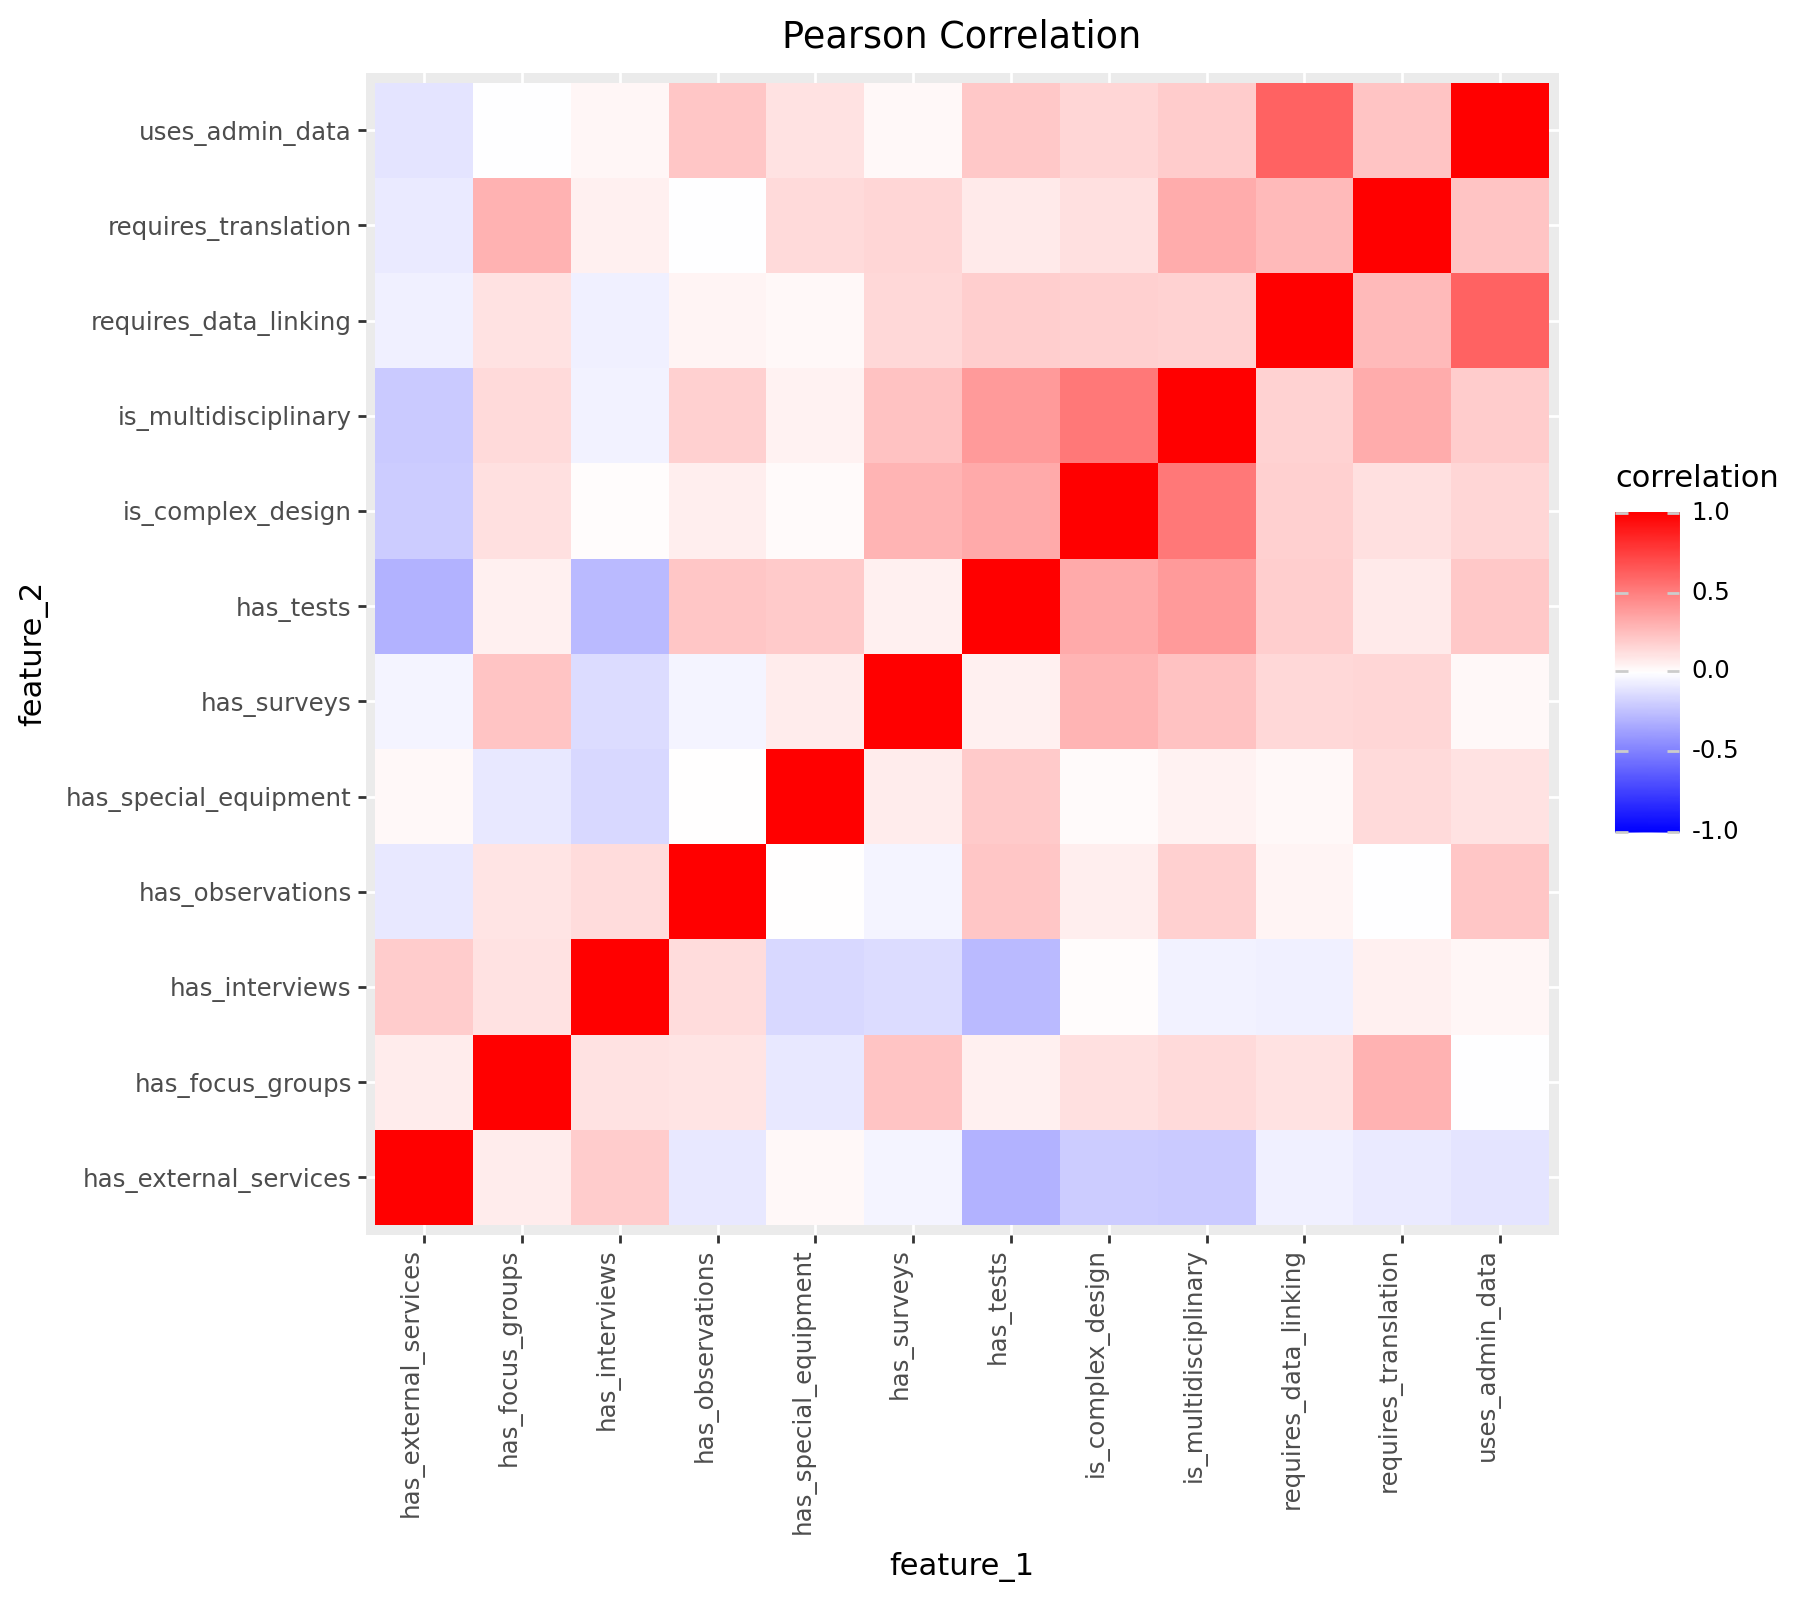

In [98]:
corr_heatmap(linear_corr_binary, "Pearson Correlation")

In [99]:
linear_corr_cross = df_clean[numeric_cols].corr(method="pearson")
linear_corr_cross

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,languages_count,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,has_special_equipment,is_multidisciplinary,target_budget
duration_months,1.000000,-0.030149,0.240052,0.147206,0.566380,0.185447,0.063437,0.207288,0.344196,0.511280,0.108666,-0.057310,0.234777,0.153503,0.388925,0.609122,-0.222371,0.185896,0.430171,0.624639
site_count,-0.030149,1.000000,0.488942,0.010469,-0.101831,0.214108,-0.012667,-0.036022,-0.057403,0.021987,0.271170,0.216063,0.275958,0.524118,-0.098211,0.136482,-0.020368,-0.110221,-0.104375,0.117471
subject_count,0.240052,0.488942,1.000000,0.318294,0.311530,0.200295,0.095639,0.308454,-0.054330,0.140419,0.216596,0.213953,0.190096,0.440297,0.132978,0.279989,-0.014072,-0.150574,0.215179,0.294227
target_populations_count,0.147206,0.010469,0.318294,1.000000,0.284235,0.138004,0.339196,0.334486,0.158388,-0.016923,0.359843,0.105176,0.166706,0.133647,0.097897,0.228283,0.070726,0.030232,0.052495,0.263483
data_waves_count,0.566380,-0.101831,0.311530,0.284235,1.000000,0.008628,0.095130,0.349793,0.260505,0.367331,0.016672,0.105747,0.183255,0.170053,0.237201,0.373371,-0.159049,0.104012,0.228955,0.404000
has_surveys,0.185447,0.214108,0.200295,0.138004,0.008628,1.000000,-0.135034,0.228037,-0.046268,0.061001,0.030688,0.163912,0.027656,0.154939,0.295790,0.103475,-0.040640,0.072267,0.237812,0.126199
has_interviews,0.063437,-0.012667,0.095639,0.339196,0.095130,-0.135034,1.000000,0.114257,0.133497,-0.271657,0.235866,0.062654,0.034482,-0.058656,0.012228,0.126890,0.198841,-0.156497,-0.050382,0.139460
has_focus_groups,0.207288,-0.036022,0.308454,0.334486,0.349793,0.228037,0.114257,1.000000,0.105304,0.059064,0.141765,0.298732,-0.002765,0.109917,0.120873,0.158427,0.072849,-0.090606,0.146374,0.203130
has_observations,0.344196,-0.057403,-0.054330,0.158388,0.260505,-0.046268,0.133497,0.105304,1.000000,0.219918,0.117135,-0.003218,0.223978,0.042334,0.070159,0.426484,-0.089175,0.005836,0.186232,0.406322
has_tests,0.511280,0.021987,0.140419,-0.016923,0.367331,0.061001,-0.271657,0.059064,0.219918,1.000000,-0.005559,0.082920,0.215972,0.192342,0.332879,0.359362,-0.302225,0.204034,0.397304,0.363549


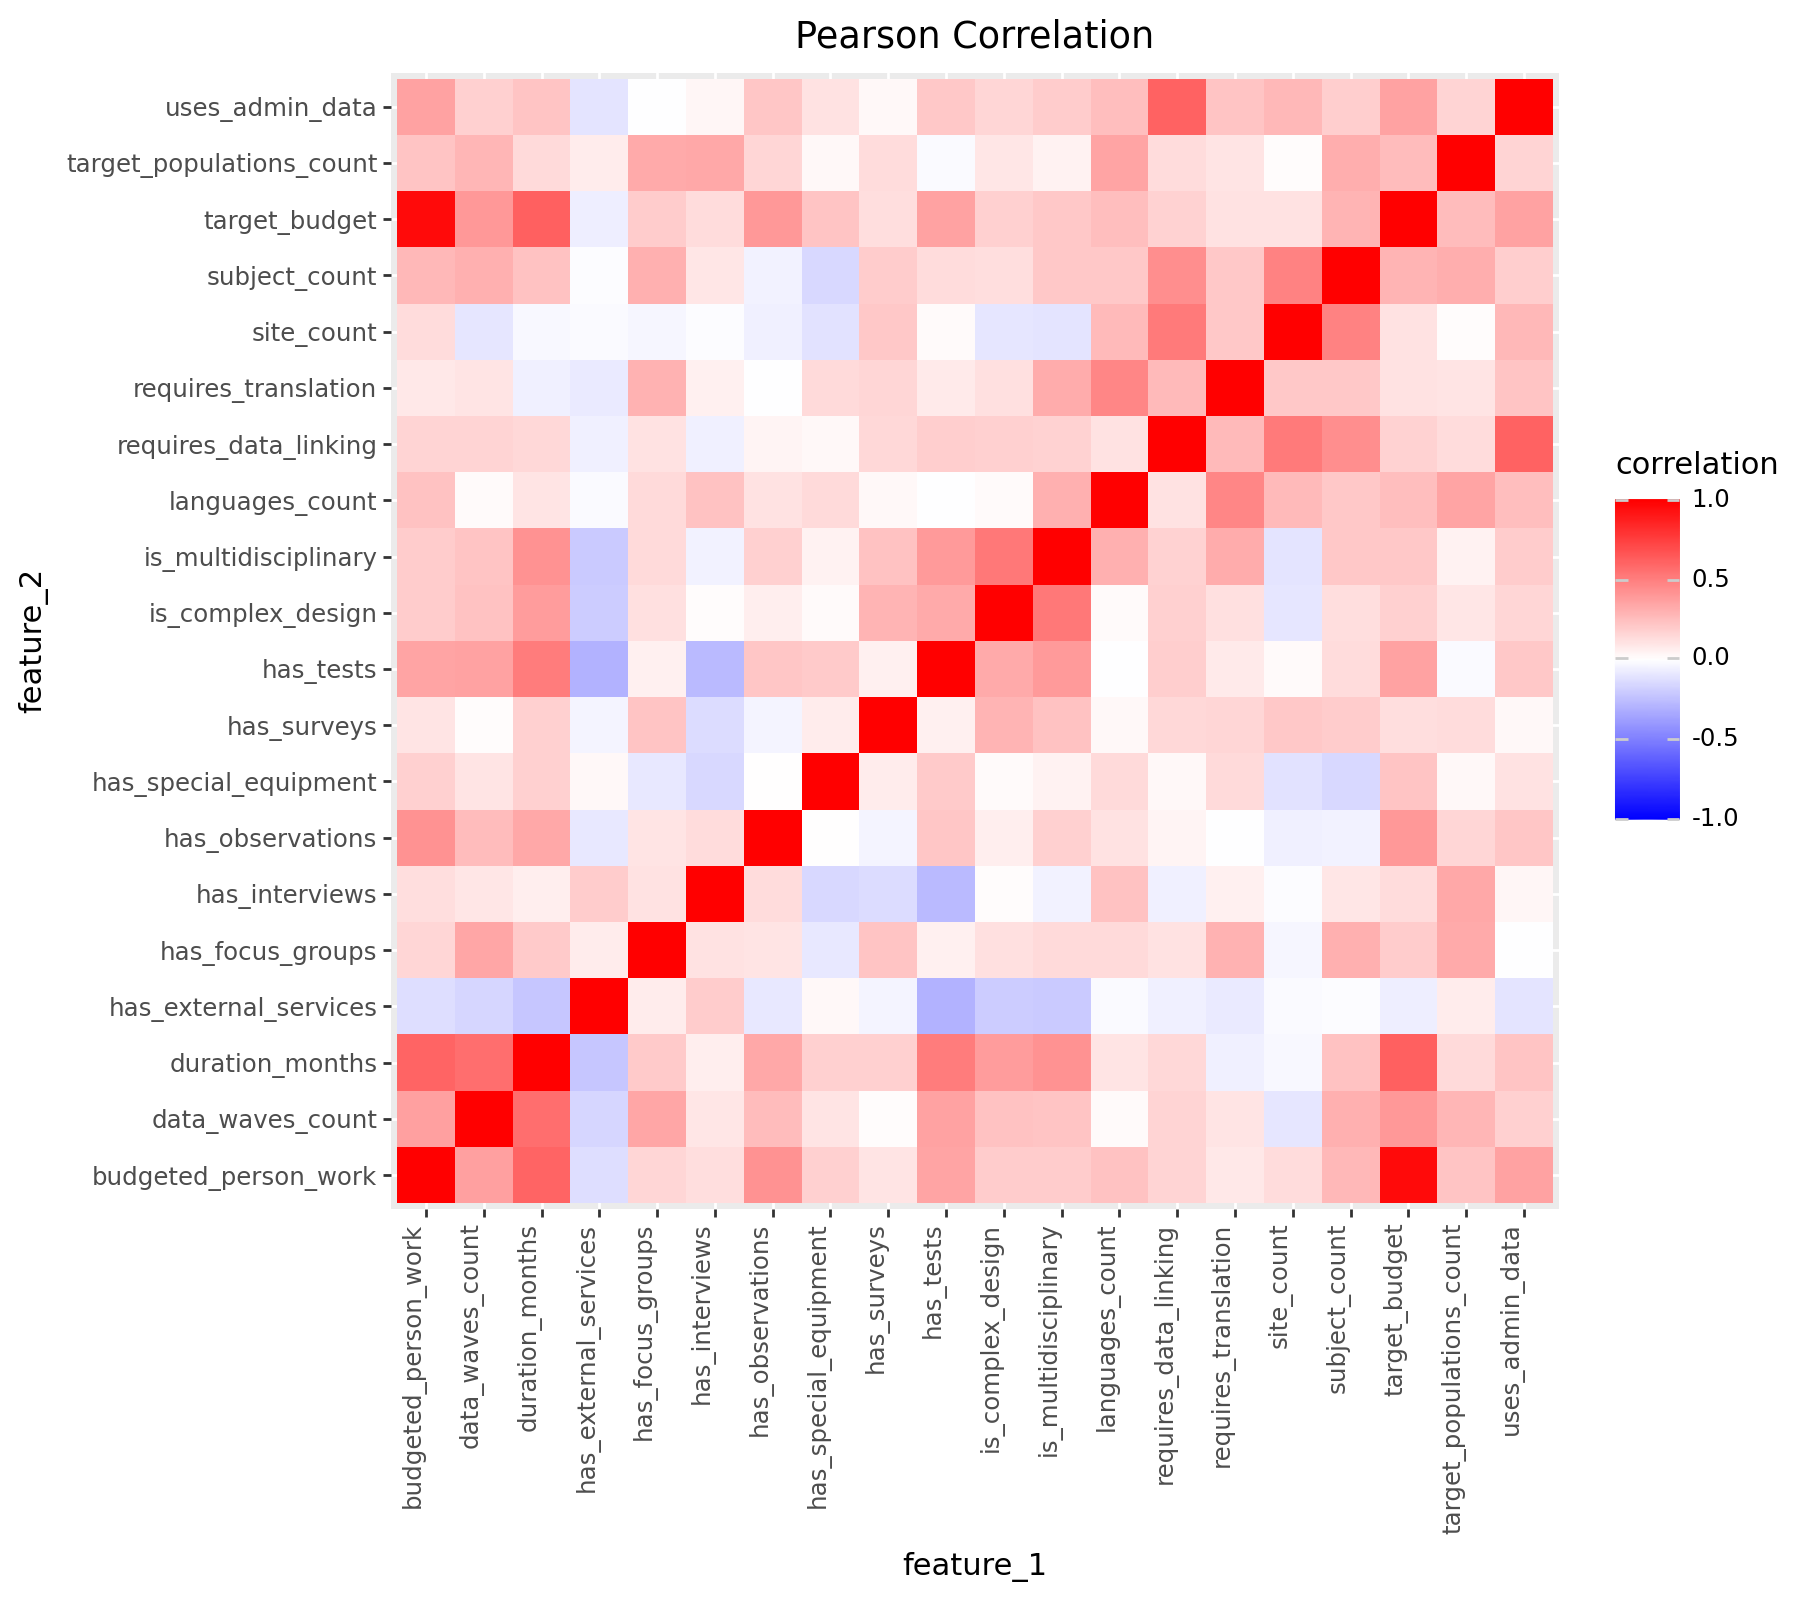

In [100]:
corr_heatmap(linear_corr_cross, "Pearson Correlation")

##### *Spearman corelation analysis*

In [101]:
mono_corr_continuous = df_clean[continuous_cols].corr(method="spearman")
mono_corr_continuous

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,languages_count,budgeted_person_work,target_budget
duration_months,1.000000,0.043041,0.161985,0.123004,0.512940,0.069929,0.667352,0.806349
site_count,0.043041,1.000000,0.353418,0.168411,-0.027844,0.265782,-0.006366,0.130478
subject_count,0.161985,0.353418,1.000000,0.262938,0.166714,0.186416,0.138644,0.247746
target_populations_count,0.123004,0.168411,0.262938,1.000000,0.281293,0.375357,0.271638,0.267751
data_waves_count,0.512940,-0.027844,0.166714,0.281293,1.000000,-0.026206,0.470050,0.531616
languages_count,0.069929,0.265782,0.186416,0.375357,-0.026206,1.000000,-0.046717,0.074208
budgeted_person_work,0.667352,-0.006366,0.138644,0.271638,0.470050,-0.046717,1.000000,0.730721
target_budget,0.806349,0.130478,0.247746,0.267751,0.531616,0.074208,0.730721,1.000000


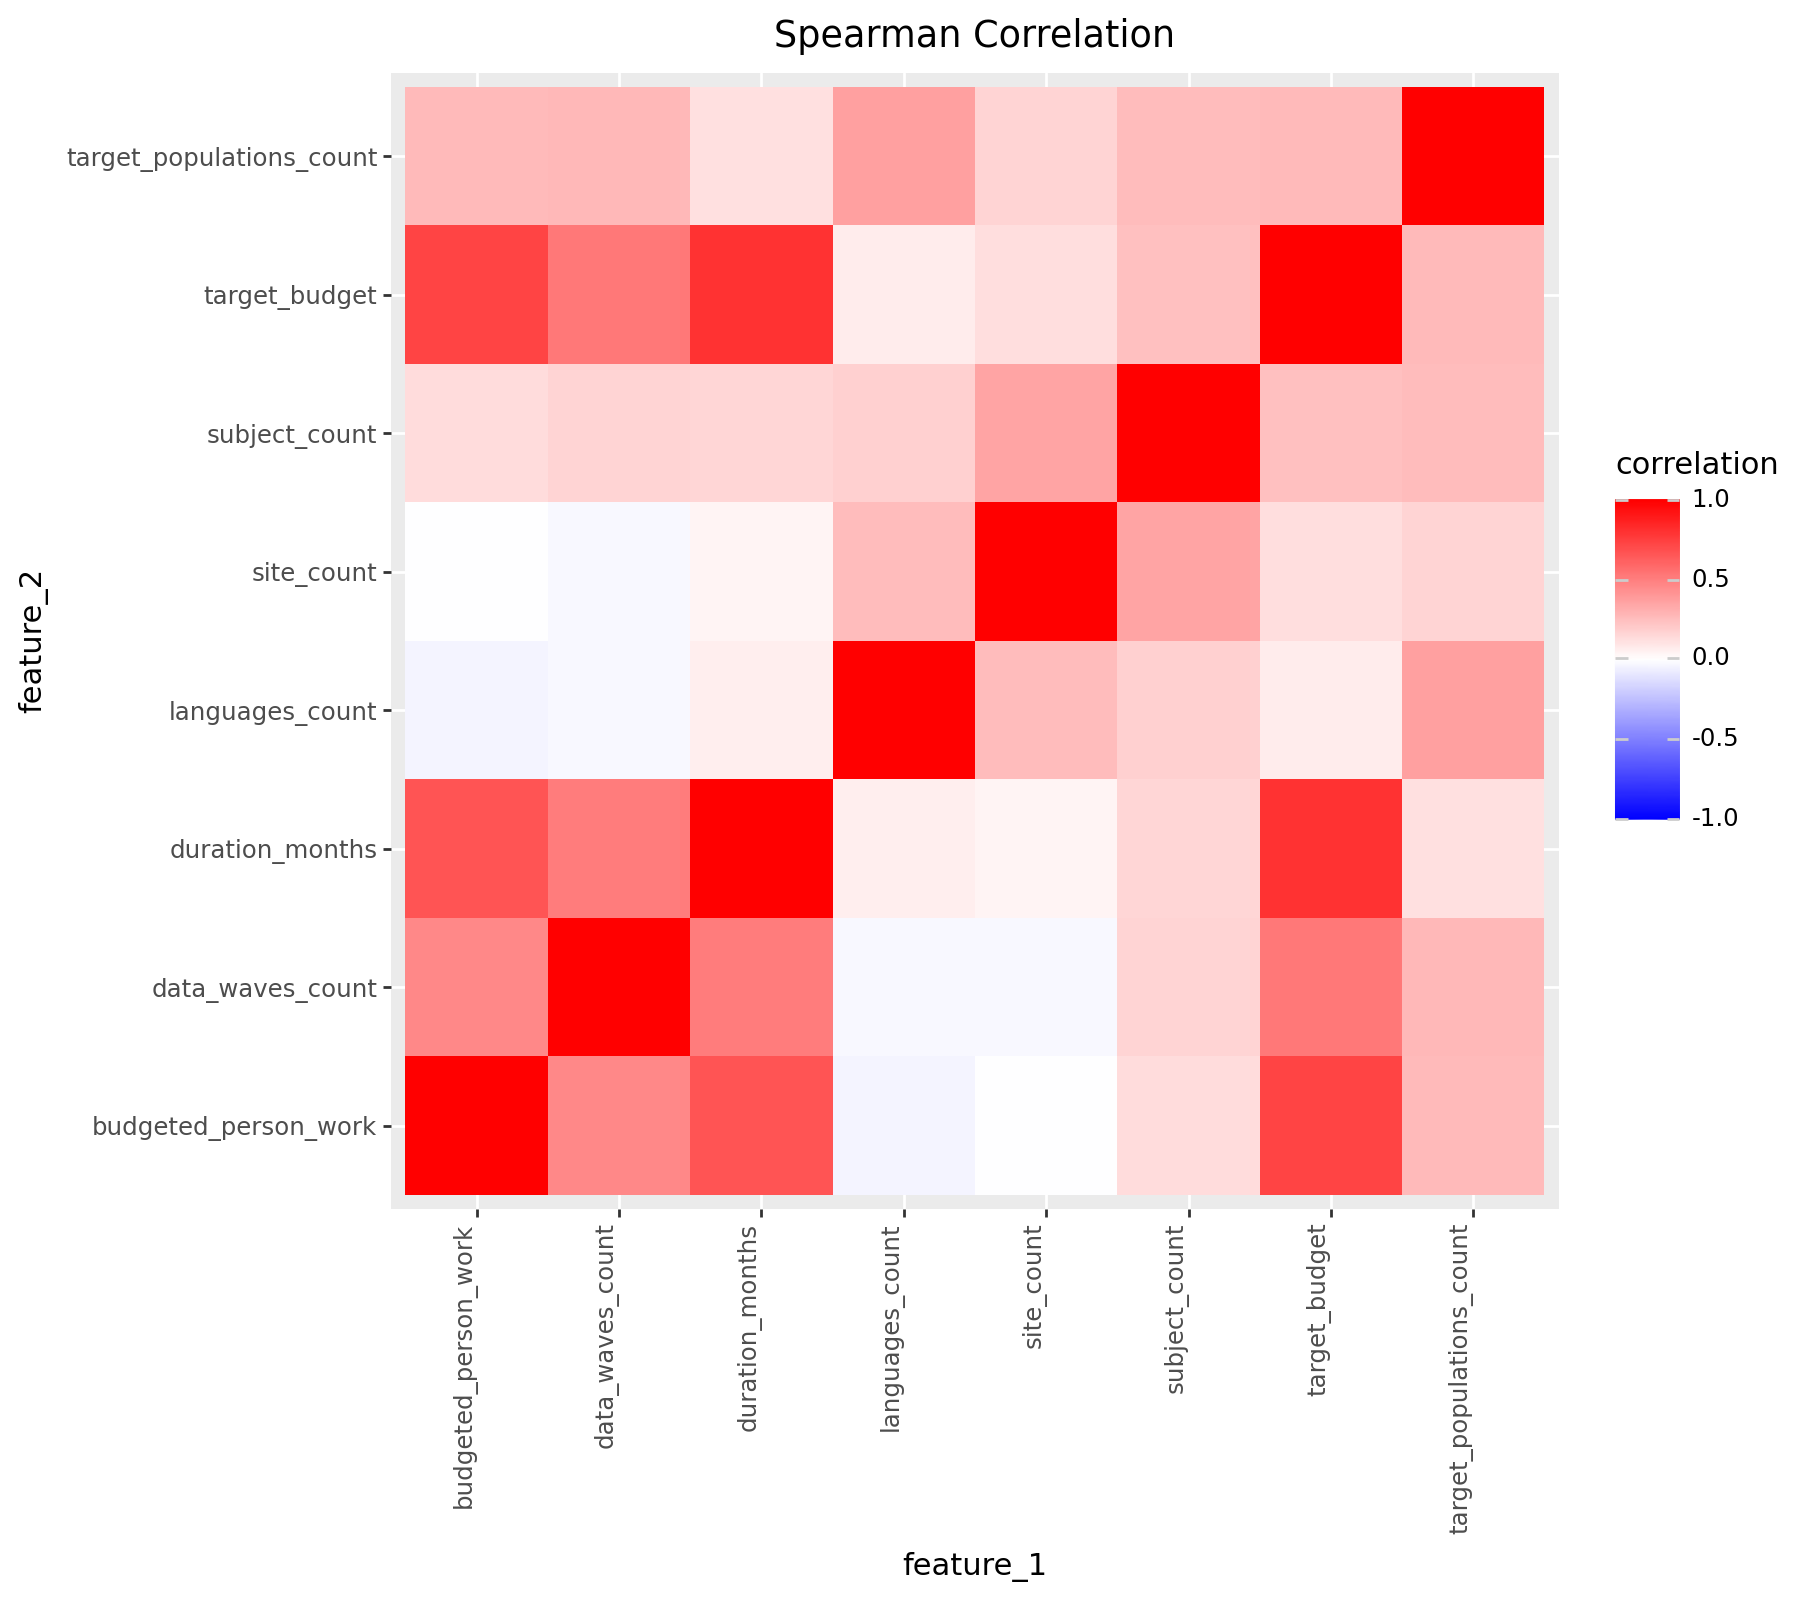

In [102]:
corr_heatmap(mono_corr_continuous, "Spearman Correlation")

In [103]:
mono_corr_binary = df_clean[binary_cols].corr(method="spearman")
mono_corr_binary

,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,has_external_services,has_special_equipment,is_multidisciplinary
has_surveys,1.000000,-0.135034,0.228037,-0.046268,0.061001,0.163912,0.027656,0.154939,0.295790,-0.040640,0.072267,0.237812
has_interviews,-0.135034,1.000000,0.114257,0.133497,-0.271657,0.062654,0.034482,-0.058656,0.012228,0.198841,-0.156497,-0.050382
has_focus_groups,0.228037,0.114257,1.000000,0.105304,0.059064,0.298732,-0.002765,0.109917,0.120873,0.072849,-0.090606,0.146374
has_observations,-0.046268,0.133497,0.105304,1.000000,0.219918,-0.003218,0.223978,0.042334,0.070159,-0.089175,0.005836,0.186232
has_tests,0.061001,-0.271657,0.059064,0.219918,1.000000,0.082920,0.215972,0.192342,0.332879,-0.302225,0.204034,0.397304
requires_translation,0.163912,0.062654,0.298732,-0.003218,0.082920,1.000000,0.232350,0.271288,0.120011,-0.085410,0.141946,0.323814
uses_admin_data,0.027656,0.034482,-0.002765,0.223978,0.215972,0.232350,1.000000,0.616417,0.163967,-0.104145,0.111009,0.196894
requires_data_linking,0.154939,-0.058656,0.109917,0.042334,0.192342,0.271288,0.616417,1.000000,0.182534,-0.055859,0.028569,0.173528
is_complex_design,0.295790,0.012228,0.120873,0.070159,0.332879,0.120011,0.163967,0.182534,1.000000,-0.201236,0.022727,0.526486
has_external_services,-0.040640,0.198841,0.072849,-0.089175,-0.302225,-0.085410,-0.104145,-0.055859,-0.201236,1.000000,0.025679,-0.206331


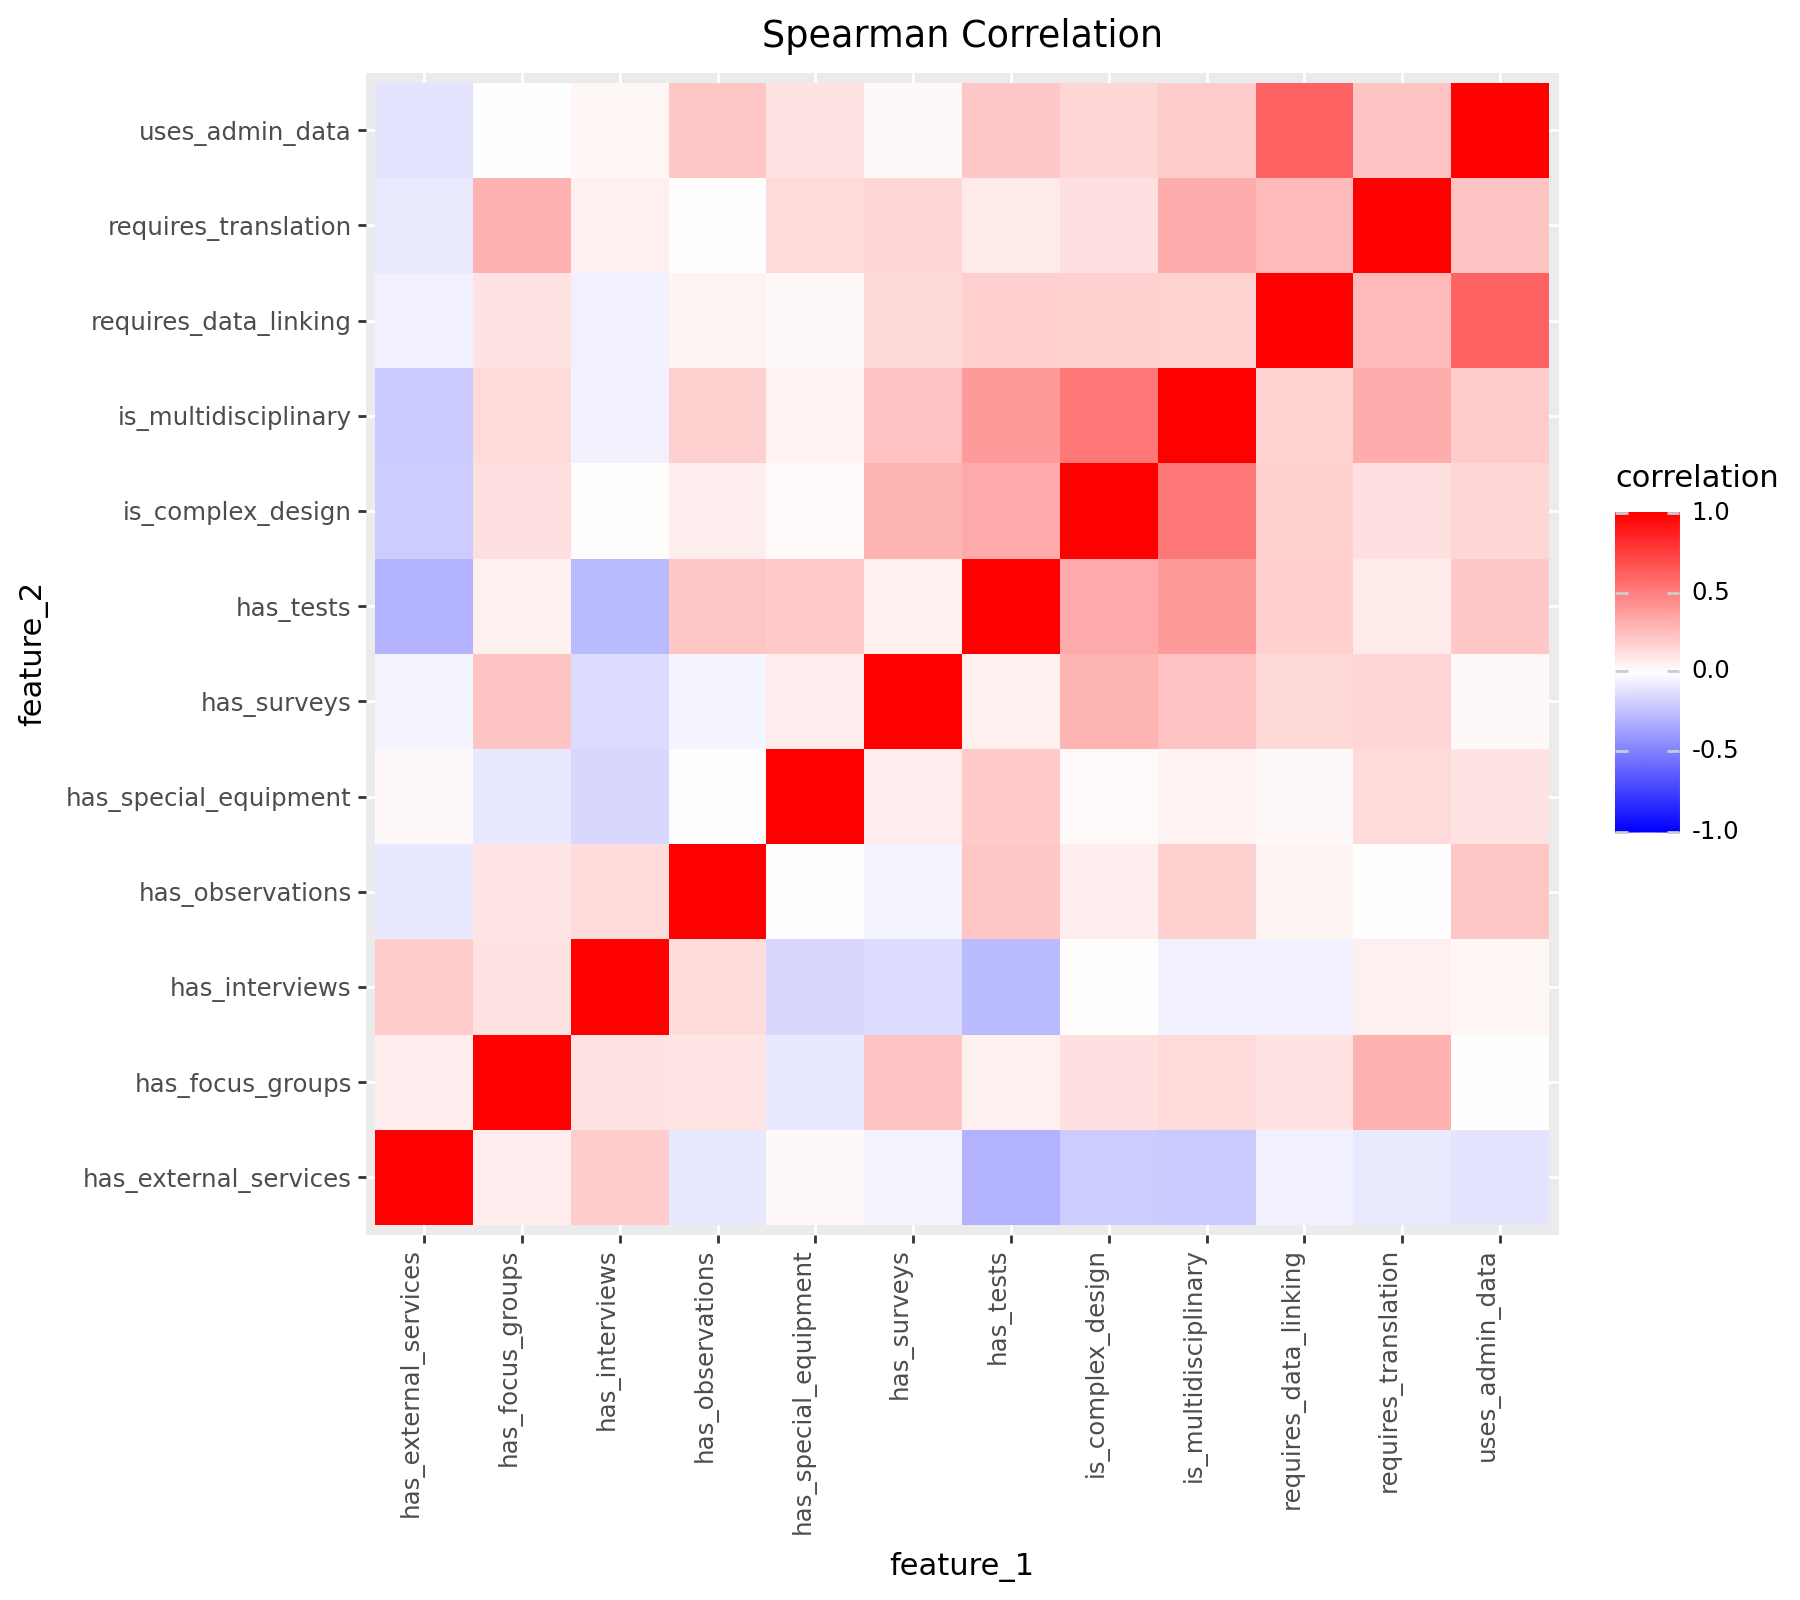

In [104]:
corr_heatmap(mono_corr_binary, "Spearman Correlation")

In [105]:
mono_corr_cross = df_clean[numeric_cols].corr(method="spearman")
mono_corr_cross

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,languages_count,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,has_special_equipment,is_multidisciplinary,target_budget
duration_months,1.000000,0.043041,0.161985,0.123004,0.512940,0.195340,0.021278,0.172800,0.329916,0.528190,0.069929,-0.067051,0.149712,0.133543,0.433863,0.667352,-0.189273,0.189817,0.493243,0.806349
site_count,0.043041,1.000000,0.353418,0.168411,-0.027844,0.289199,0.078071,0.067443,-0.057168,0.075992,0.265782,0.165956,0.225599,0.490808,0.040179,-0.006366,-0.078071,-0.055733,0.043077,0.130478
subject_count,0.161985,0.353418,1.000000,0.262938,0.166714,0.511766,-0.067380,0.331143,-0.160858,0.025862,0.186416,0.182243,0.013640,0.117459,0.214488,0.138644,-0.023108,-0.164142,0.193609,0.247746
target_populations_count,0.123004,0.168411,0.262938,1.000000,0.281293,0.126467,0.359632,0.365340,0.122697,0.012858,0.375357,0.101538,0.225205,0.179699,0.160511,0.271638,0.037070,0.054697,0.088187,0.267751
data_waves_count,0.512940,-0.027844,0.166714,0.281293,1.000000,0.034052,0.077199,0.332689,0.277149,0.367130,-0.026206,0.085844,0.134937,0.139650,0.242625,0.470050,-0.149857,0.103379,0.230157,0.531616
has_surveys,0.195340,0.289199,0.511766,0.126467,0.034052,1.000000,-0.135034,0.228037,-0.046268,0.061001,0.025378,0.163912,0.027656,0.154939,0.295790,0.055588,-0.040640,0.072267,0.237812,0.241549
has_interviews,0.021278,0.078071,-0.067380,0.359632,0.077199,-0.135034,1.000000,0.114257,0.133497,-0.271657,0.243810,0.062654,0.034482,-0.058656,0.012228,0.007771,0.198841,-0.156497,-0.050382,-0.023651
has_focus_groups,0.172800,0.067443,0.331143,0.365340,0.332689,0.228037,0.114257,1.000000,0.105304,0.059064,0.122769,0.298732,-0.002765,0.109917,0.120873,0.159838,0.072849,-0.090606,0.146374,0.193186
has_observations,0.329916,-0.057168,-0.160858,0.122697,0.277149,-0.046268,0.133497,0.105304,1.000000,0.219918,0.084136,-0.003218,0.223978,0.042334,0.070159,0.438225,-0.089175,0.005836,0.186232,0.365534
has_tests,0.528190,0.075992,0.025862,0.012858,0.367130,0.061001,-0.271657,0.059064,0.219918,1.000000,-0.025541,0.082920,0.215972,0.192342,0.332879,0.428760,-0.302225,0.204034,0.397304,0.469189


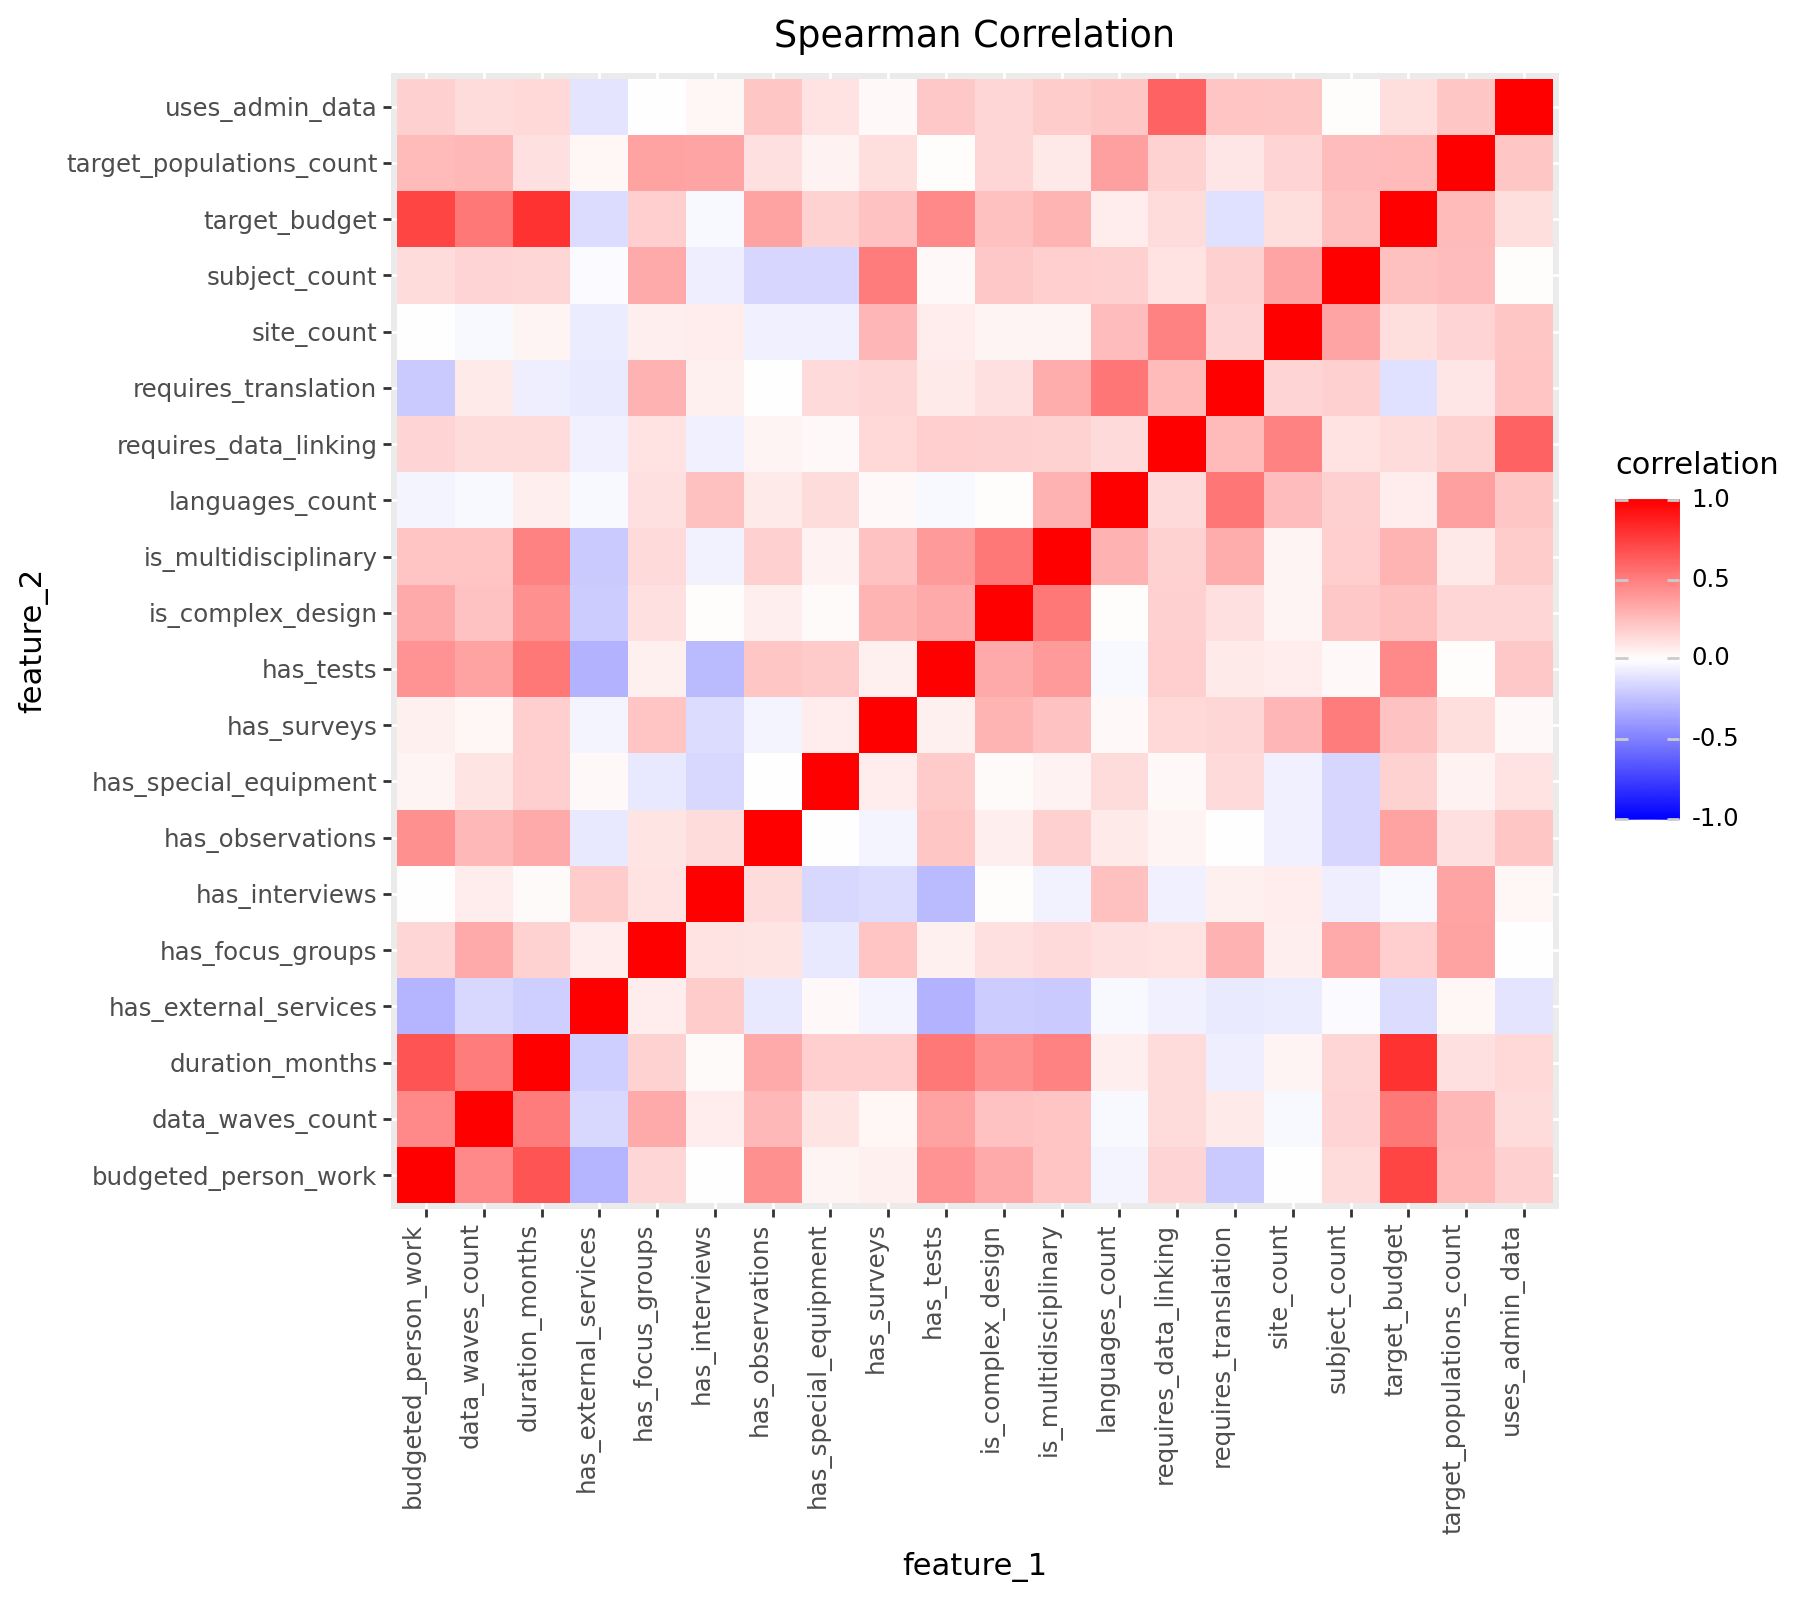

In [106]:
corr_heatmap(mono_corr_cross, "Spearman Correlation")

##### *Conclusion*

In [111]:
def build_correlation_table (df, cols):
    pearson = df[cols].corr(method="pearson")   # nXn correlation matrix
    spearman = df[cols].corr(method="spearman")
    rows = [] # dictionary that will collect pair of correlated variables
    for i, first_col in enumerate(cols): # i = index, first_col = columns name
        for second_col in cols[i+1:]: # only columns after first_col will be allocted to the ist
            p = pearson.loc[first_col, second_col] # calc pearson corr for the 2 columns
            s = spearman.loc[first_col, second_col] # calc spearman corr for the 2 cols
            if pd.isna(p) and pd.isna(s):
                continue    # skip undefined corr values
            p_abs = abs(p) if pd.isna(p) else -1    # absolute Pearson value, or -1 placeholder if missing
            s_abs = abs(s) if pd.isna(s) else -1    # absolute spearman value, or -1 placeholder if missing
            if p_abs >= s_abs:
                relationship, strength = "Linear (Pearson)", p
            else:
                relationship, strength = "Monotonic (Spearman)", s
            rows.append({   # append this pair's result as one row (dict) to the rows list
                "var1": first_col,
                "var2": second_col,
                "relationship": relationship,
                "strength": round(strength,3)
            })

        result = pd.DataFrame(rows) # convert list to df
        result["abs_strength"] = result["strength"].abs()   # temporary column, used only for sorting
        result.sort_values(by="abs_strength", ascending=False).drop(columns=["abs_strength"])   # sort by strongest relationship first, then remove the helper column
        return result.reset_index(drop=True)    # renumber rows 0,1,2,... after sorting


In [116]:
import pandas as pd
import numpy as np

def build_correlation_table(df, cols):
    """
    Build a long-format table with one row per pair of columns.
    For each pair, compute both Pearson and Spearman correlations,
    then keep whichever has the larger absolute value (the "winning" method).
    Columns: var1, var2, relationship (Linear/Monotonic), strength (signed value).
    """
    pearson = df[cols].corr(method="pearson")     # full NxN Pearson correlation matrix
    spearman = df[cols].corr(method="spearman")   # full NxN Spearman correlation matrix

    rows = []  # will collect one dict per unique pair of columns
    for i, c1 in enumerate(cols):        # i = index of c1 in the cols list; c1 = column name itself
        for c2 in cols[i+1:]:            # only pairs AFTER c1 in the list -> avoids (A,B) and (B,A) duplicates, and A vs A
            p = pearson.loc[c1, c2]      # Pearson value for this specific pair
            s = spearman.loc[c1, c2]     # Spearman value for this specific pair
            if pd.isna(p) and pd.isna(s):
                continue                 # skip pairs where both correlations are undefined (e.g., no overlapping data)
            p_abs = abs(p) if pd.notna(p) else -1   # absolute Pearson value, or -1 placeholder if missing
            s_abs = abs(s) if pd.notna(s) else -1   # absolute Spearman value, or -1 placeholder if missing
            if p_abs >= s_abs:
                relationship, strength = "Linear (Pearson)", p       # Pearson wins -> relationship is linear
            else:
                relationship, strength = "Monotonic (Spearman)", s   # Spearman wins -> relationship is monotonic
            rows.append({"var1": c1, "var2": c2, "relationship": relationship, "strength": round(strength, 3)})
            # append this pair's result as one row (dict) to the rows list

    result = pd.DataFrame(rows)                          # convert list of dicts into a DataFrame
    result["abs_strength"] = result["strength"].abs()    # temporary column, used only for sorting
    result = result.sort_values("abs_strength", ascending=False).drop(columns="abs_strength")
    # sort by strongest relationship first, then remove the helper column
    return result.reset_index(drop=True)   # renumber rows 0,1,2,... after sorting


# df_clean: dataframe with -1 / "Unknown" already replaced by NaN
# numeric_cols: list of all numeric columns (continuous + binary)

full_corr_table = build_correlation_table(df_clean, numeric_cols)   # run the function once on the full column list

# Table 1: top 20 strongest relationships across the whole dataset
top20_overall = full_corr_table.head(20)   # first 20 rows = 20 strongest, since table is already sorted

# Table 2: top 10 strongest relationships for a specific target variable
target_col = "budgeted_person_work"   # <-- change to whichever variable is your target

target_table = full_corr_table[
    (full_corr_table["var1"] == target_col) | (full_corr_table["var2"] == target_col)
].copy()   # keep only rows where the target variable appears in either column; .copy() avoids a pandas warning later

# Make sure the target variable always appears in var1, for readability
def put_target_first(row):
    if row["var2"] == target_col:               # if target is in var2, swap var1/var2 so target is always first
        return pd.Series({"var1": row["var2"], "var2": row["var1"],
                           "relationship": row["relationship"], "strength": row["strength"]})
    return row   # already in the right order, leave unchanged

target_table = target_table.apply(put_target_first, axis=1)   # apply the swap row-by-row (axis=1 = row-wise)
top10_target = target_table.head(10).reset_index(drop=True)   # first 10 rows + reset row numbering

display(top20_overall)   # Jupyter-friendly table display
display(top10_target)

,var1,var2,relationship,strength
0,budgeted_person_work,target_budget,Linear (Pearson),0.961
1,duration_months,target_budget,Monotonic (Spearman),0.806
2,duration_months,budgeted_person_work,Monotonic (Spearman),0.667
3,uses_admin_data,requires_data_linking,Monotonic (Spearman),0.616
4,duration_months,data_waves_count,Linear (Pearson),0.566
5,languages_count,requires_translation,Monotonic (Spearman),0.540
6,data_waves_count,target_budget,Monotonic (Spearman),0.532
7,duration_months,has_tests,Monotonic (Spearman),0.528
8,is_complex_design,is_multidisciplinary,Monotonic (Spearman),0.526
9,site_count,requires_data_linking,Linear (Pearson),0.524


,var1,var2,relationship,strength
0,budgeted_person_work,target_budget,Linear (Pearson),0.961
1,budgeted_person_work,duration_months,Monotonic (Spearman),0.667
2,budgeted_person_work,data_waves_count,Monotonic (Spearman),0.470
3,budgeted_person_work,has_observations,Monotonic (Spearman),0.438
4,budgeted_person_work,has_tests,Monotonic (Spearman),0.429
5,budgeted_person_work,uses_admin_data,Linear (Pearson),0.365
6,budgeted_person_work,is_complex_design,Monotonic (Spearman),0.335
7,budgeted_person_work,has_external_services,Monotonic (Spearman),-0.293
8,budgeted_person_work,subject_count,Linear (Pearson),0.280
9,budgeted_person_work,target_populations_count,Monotonic (Spearman),0.272
